## **Machine Learning Aplicado a las Finanzas**
### **HW Sesion 3 - Walk-Forward, Leakage y Nested CV Temporal**

**Alumno:** Alejandro Alvear  
**Curso:** Machine Learning Aplicado a las Finanzas  
**Entrega:** HW Sesion 3

---

Este notebook resuelve la tarea usando datos descargados con `yfinance`. El foco principal es evitar data leakage en pipelines financieros y evaluar modelos respetando el orden temporal de los datos.


## Setup

Se definen imports, configuracion grafica y funciones auxiliares para que el notebook sea robusto ante distintas versiones de `yfinance`.


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf

from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_style("darkgrid")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
RANDOM_STATE = 42


def extract_close(raw, ticker=None):
    """Devuelve una Serie de cierre aunque yfinance retorne columnas MultiIndex."""
    close = raw["Close"]
    if isinstance(close, pd.DataFrame):
        if ticker is not None and ticker in close.columns:
            series = close[ticker]
        else:
            series = close.iloc[:, 0]
    else:
        series = close
    series = series.dropna().copy()
    series.name = ticker or "Close"
    return series


def _rsi(ret, window=14):
    """RSI simple calculado sobre una serie de retornos ya desplazada cuando corresponde."""
    gain = ret.clip(lower=0).rolling(window).mean()
    loss = (-ret.clip(upper=0)).rolling(window).mean()
    rs = gain / (loss + 1e-9)
    return 100 - (100 / (1 + rs))


def score_for_auc(fitted_model, X):
    """Obtiene score continuo para AUC: probabilidad si existe, margen si es SVM."""
    if hasattr(fitted_model, "predict_proba"):
        try:
            return fitted_model.predict_proba(X)[:, 1]
        except Exception as exc:
            _ = exc
    if hasattr(fitted_model, "decision_function"):
        return fitted_model.decision_function(X)
    return fitted_model.predict(X)


---
## Parte 1 - Auditoria de Data Leakage

El primer bloque reproduce el pipeline defectuoso con tres formas de leakage: rolling centrado, label mal definido y normalizacion ajustada antes del split.


In [2]:
raw = yf.download("SPY", start="2015-01-01", end="2024-12-31", auto_adjust=True, progress=False)
ret = extract_close(raw, "SPY").pct_change().dropna()
ret.name = "ret"
print(f"Serie SPY: {ret.index[0].date()} - {ret.index[-1].date()} | {len(ret):,} observaciones")


Serie SPY: 2015-01-05 - 2024-12-30 | 2,514 observaciones


In [3]:
def build_pipeline_bad(ret):
    """Pipeline defectuoso con tres leakages ocultos. No debe usarse en produccion."""
    df = pd.DataFrame({"ret": ret})

    # LEAKAGE A: rolling centrado incluye datos futuros.
    df["vol_20"] = df["ret"].rolling(20, center=True).std()
    df["mean_10"] = df["ret"].rolling(10, center=True).mean()
    df["ret_lag1"] = df["ret"].shift(1)

    # LEAKAGE B: label de hoy en lugar del retorno futuro.
    df["label"] = (df["ret"] > 0).astype(int)

    df = df.dropna()
    X = df[["ret_lag1", "vol_20", "mean_10"]].values
    y = df["label"].values

    # LEAKAGE C: scaler ajustado sobre toda la muestra antes del split.
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    cut = int(len(X_scaled) * 0.7)
    return X_scaled[:cut], X_scaled[cut:], y[:cut], y[cut:]


X_tr_bad, X_te_bad, y_tr_bad, y_te_bad = build_pipeline_bad(ret)
model_bad = LogisticRegression(C=0.1, max_iter=1000).fit(X_tr_bad, y_tr_bad)
auc_bad = roc_auc_score(y_te_bad, model_bad.predict_proba(X_te_bad)[:, 1])
print(f"AUC pipeline defectuoso: {auc_bad:.4f}")


AUC pipeline defectuoso: 0.6214


### 1.1 y 1.2 - Leakages identificados

| # | Tipo de leakage | Linea exacta del codigo | Problema en trading real |
|---|-----------------|-------------------------|---------------------------|
| A | Rolling temporal | `df["vol_20"] = df["ret"].rolling(20, center=True).std()` y `df["mean_10"] = df["ret"].rolling(10, center=True).mean()` | Al usar `center=True`, la ventana incorpora retornos posteriores a la fecha de decision. En trading real esos retornos aun no existen, por lo que el backtest queda contaminado con informacion futura. |
| B | Label mal desplazado | `df["label"] = (df["ret"] > 0).astype(int)` | El modelo predice la direccion del retorno del mismo dia. En operacion real se necesita predecir `t+1` con informacion disponible hasta `t`. |
| C | Normalizacion antes del split | `X_scaled = scaler.fit_transform(X)` | El `StandardScaler` aprende media y desviacion usando train y test al mismo tiempo. En un sistema real, esos parametros solo pueden estimarse con el periodo de entrenamiento. |


### 1.3 - Pipeline correcto

Correcciones aplicadas:

- Features rolling construidas con informacion historica desplazada mediante `shift(1)`.
- Label definido como direccion futura: `ret.shift(-1)`.
- `StandardScaler` dentro de `sklearn.Pipeline`, de modo que se ajusta solo con `X_train`.


In [4]:
def build_pipeline_good(ret):
    """Pipeline corregido sin data leakage."""
    df = pd.DataFrame({"ret": ret})
    historical_ret = df["ret"].shift(1)

    df["ret_lag1"] = df["ret"].shift(1)
    df["vol_20"] = historical_ret.rolling(20, center=False).std()
    df["mean_10"] = historical_ret.rolling(10, center=False).mean()
    df["label"] = (df["ret"].shift(-1) > 0).astype(int)

    df = df.dropna()
    X = df[["ret_lag1", "vol_20", "mean_10"]]
    y = df["label"]

    cut = int(len(X) * 0.7)
    X_train, X_test = X.iloc[:cut], X.iloc[cut:]
    y_train, y_test = y.iloc[:cut], y.iloc[cut:]

    pipe = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(C=0.1, max_iter=1000))])
    pipe.fit(X_train, y_train)
    return pipe, X_train, X_test, y_train, y_test


pipe_good, X_tr_g, X_te_g, y_tr_g, y_te_g = build_pipeline_good(ret)
auc_good = roc_auc_score(y_te_g, pipe_good.predict_proba(X_te_g)[:, 1])
print(f"AUC correcto      : {auc_good:.4f}")
print(f"AUC defectuoso    : {auc_bad:.4f}")
print(f"Inflacion leakage : {auc_bad - auc_good:+.4f}")


AUC correcto      : 0.4782
AUC defectuoso    : 0.6214
Inflacion leakage : +0.1433


**Conclusion Parte 1.** El pipeline defectuoso muestra un AUC artificialmente superior porque el modelo recibe informacion que no estaria disponible al momento de operar. La diferencia entre ambos AUC cuantifica la inflacion generada por leakage. En un contexto de trading, esto llevaria a sobreestimar la capacidad predictiva y a tomar decisiones de inversion con un backtest poco realista.


---
## Parte 2 - Walk-Forward con Rolling Window

Se trabaja con AAPL entre 2015 y 2024. La comparacion central es entre walk-forward con ventana expansiva y walk-forward con ventana rolling fija.


In [5]:
raw_aapl = yf.download("AAPL", start="2015-01-01", end="2024-12-31", auto_adjust=True, progress=False)
ret_aapl = extract_close(raw_aapl, "AAPL").pct_change().dropna()
ret_aapl.name = "ret"
print(f"AAPL: {ret_aapl.index[0].date()} - {ret_aapl.index[-1].date()} | {len(ret_aapl):,} obs")


def build_features_aapl(ret, horizonte=1):
    """Features anti-leakage para AAPL."""
    r = ret.copy()
    historical_ret = r.shift(1)
    df = pd.DataFrame(index=r.index)

    for lag in [1, 2, 5, 10]:
        df[f"ret_lag_{lag}"] = r.shift(lag)

    df["rolling_mean_5"] = historical_ret.rolling(5).mean()
    df["rolling_mean_20"] = historical_ret.rolling(20).mean()
    df["vol_10"] = historical_ret.rolling(10).std()
    df["vol_20"] = historical_ret.rolling(20).std()
    df["rsi_14"] = _rsi(historical_ret, 14)
    df["skew_20"] = historical_ret.rolling(20).skew()
    df["label"] = (r.shift(-horizonte) > 0).astype(int)

    return df.dropna()


feat = build_features_aapl(ret_aapl)
X = feat.drop(columns=["label"])
y = feat["label"]
print(f"Dataset AAPL: {X.shape[0]} obs | {X.shape[1]} features | {y.mean():.2%} dias alcistas")
display(feat.head())


AAPL: 2015-01-05 - 2024-12-30 | 2,514 obs
Dataset AAPL: 2494 obs | 10 features | 53.13% dias alcistas


,ret_lag_1,ret_lag_2,ret_lag_5,ret_lag_10,rolling_mean_5,rolling_mean_20,vol_10,vol_20,rsi_14,skew_20,label
Date,,,,,,,,,,,
2015-02-03,0.012547,-0.014634,-0.035013,0.025757,0.010113,0.004358,0.025471,0.023813,66.411283,0.268012,1
2015-02-04,0.000169,0.012547,0.056533,0.007635,0.017150,0.005775,0.025176,0.022587,65.261190,0.278950,1
2015-02-05,0.007669,0.000169,0.031133,0.026015,0.007377,0.006153,0.025176,0.022551,67.255919,0.225296,0
2015-02-06,0.007138,0.007669,-0.014634,0.005160,0.002578,0.005809,0.024462,0.022477,75.898817,0.276079,1
2015-02-09,-0.008421,0.007138,0.012547,0.001063,0.003820,0.003467,0.024958,0.021310,75.692073,0.464847,1


In [6]:
class WalkForwardRolling:
    """Walk-Forward con ventana de entrenamiento de tamano fijo."""

    def __init__(self, train_size, test_size, gap=0, step=None):
        self.train_size = int(train_size)
        self.test_size = int(test_size)
        self.gap = int(gap)
        self.step = int(test_size if step is None else step)

        if self.train_size <= 0:
            raise ValueError("train_size debe ser positivo")
        if self.test_size <= 0:
            raise ValueError("test_size debe ser positivo")
        if self.step <= 0:
            raise ValueError("step debe ser positivo")
        if self.gap < 0:
            raise ValueError("gap no puede ser negativo")

    def split(self, X):
        """Generador que devuelve (train_indices, test_indices) por fold."""
        n = len(X)
        train_start = 0
        while True:
            train_end = train_start + self.train_size
            test_start = train_end + self.gap
            test_end = test_start + self.test_size
            if test_end > n:
                break
            yield np.arange(train_start, train_end), np.arange(test_start, test_end)
            train_start += self.step

    def get_n_splits(self, X):
        """Numero total de folds."""
        return sum(1 for _ in self.split(X))


def _test_wfr():
    n = 300
    X_dummy = np.arange(n)
    wfr = WalkForwardRolling(train_size=80, test_size=20, gap=5, step=10)
    splits = list(wfr.split(X_dummy))
    assert len(splits) > 0, "No se generaron folds"
    for tr, te in splits:
        assert len(tr) == 80, f"Train size incorrecto: {len(tr)} != 80"
        assert len(te) == 20, f"Test size incorrecto: {len(te)} != 20"
        assert te[0] - tr[-1] > 5, f"Gap no respetado: {te[0] - tr[-1]}"
    assert wfr.get_n_splits(X_dummy) == len(splits), "get_n_splits inconsistente"
    print(f"Test WalkForwardRolling: OK - {len(splits)} folds generados")


_test_wfr()


Test WalkForwardRolling: OK - 20 folds generados


,Estrategia,AUC media,AUC std,Folds>0.5,n_folds
0,Expanding,0.5019,0.0784,0.5192,104
1,Rolling,0.5016,0.0678,0.5096,104


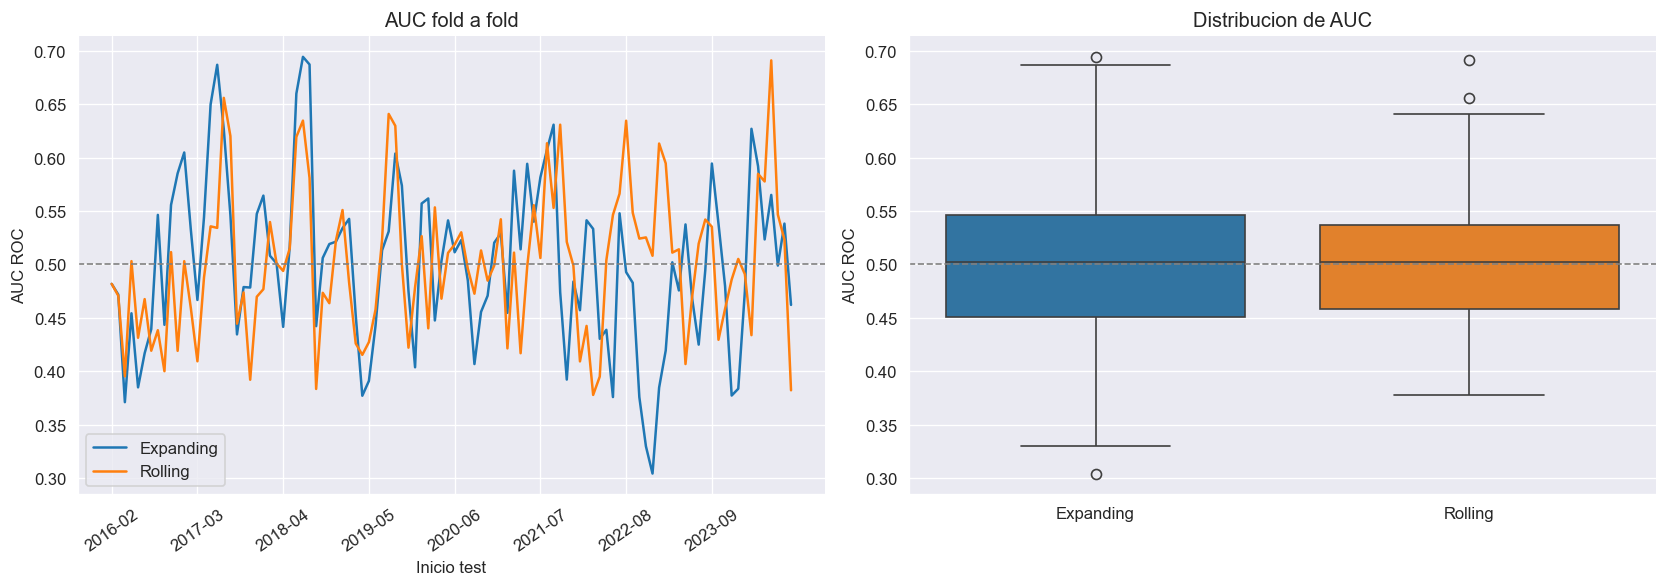

In [7]:
INITIAL_TRAIN = 252
ROLLING_TRAIN = 252
TEST_SIZE = 63
GAP = 5
STEP = 21

pipe_base = Pipeline([
    ("imp", SimpleImputer()),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(C=0.1, max_iter=1000)),
])

aucs_expanding = []
dates_expanding = []
fold_indices_expanding = []
end = INITIAL_TRAIN
while end + GAP + TEST_SIZE <= len(X):
    train_idx = np.arange(0, end)
    test_idx = np.arange(end + GAP, end + GAP + TEST_SIZE)
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]
    model = clone(pipe_base).fit(X_train, y_train)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    aucs_expanding.append(auc)
    dates_expanding.append(X_test.index[0].strftime("%Y-%m"))
    fold_indices_expanding.append((train_idx, test_idx))
    end += STEP

aucs_rolling = []
dates_rolling = []
wfr = WalkForwardRolling(train_size=ROLLING_TRAIN, test_size=TEST_SIZE, gap=GAP, step=STEP)
for train_idx, test_idx in wfr.split(X):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]
    model = clone(pipe_base).fit(X_train, y_train)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    aucs_rolling.append(auc)
    dates_rolling.append(X_test.index[0].strftime("%Y-%m"))

resumen = pd.DataFrame({
    "Estrategia": ["Expanding", "Rolling"],
    "AUC media": [np.mean(aucs_expanding), np.mean(aucs_rolling)],
    "AUC std": [np.std(aucs_expanding), np.std(aucs_rolling)],
    "Folds>0.5": [np.mean(np.array(aucs_expanding) > 0.5), np.mean(np.array(aucs_rolling) > 0.5)],
    "n_folds": [len(aucs_expanding), len(aucs_rolling)],
})
display(resumen.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(dates_expanding, aucs_expanding, label="Expanding", color="#1f77b4", lw=1.5)
axes[0].plot(dates_rolling, aucs_rolling, label="Rolling", color="#ff7f0e", lw=1.5)
axes[0].axhline(0.5, ls="--", color="gray", lw=1)
axes[0].set_title("AUC fold a fold")
axes[0].set_ylabel("AUC ROC")
axes[0].set_xlabel("Inicio test")
step_ticks = max(1, len(dates_expanding) // 8)
axes[0].set_xticks(range(0, len(dates_expanding), step_ticks))
axes[0].set_xticklabels(dates_expanding[::step_ticks], rotation=35)
axes[0].legend()

auc_long = pd.DataFrame({
    "AUC": aucs_expanding + aucs_rolling,
    "Estrategia": ["Expanding"] * len(aucs_expanding) + ["Rolling"] * len(aucs_rolling),
})
sns.boxplot(data=auc_long, x="Estrategia", y="AUC", ax=axes[1], palette=["#1f77b4", "#ff7f0e"])
axes[1].axhline(0.5, ls="--", color="gray", lw=1)
axes[1].set_title("Distribucion de AUC")
axes[1].set_xlabel("")
axes[1].set_ylabel("AUC ROC")
plt.tight_layout()
plt.show()


### Respuesta Parte 2.3

En esta ejecucion, ambas estrategias quedan muy cerca de un AUC medio de 0.50, lo que indica que la prediccion diaria de direccion de AAPL es dificil con estos features simples. Rolling es levemente mas apropiada si se busca adaptacion a cambios de regimen, porque mantiene memoria fija de un ano de trading y descarta informacion antigua que puede haber dejado de representar el mercado actual. Expanding usa mas historia y puede ser util cuando se espera estabilidad estructural, pero en AAPL 2015-2024 hay periodos muy distintos, por lo que prefiero Rolling por su menor dispersion del AUC y por su logica mas adaptativa.


---
## Parte 3 - Nested CV Temporal: Comparacion de Modelos

Se construye un dataset para JPM con variables propias y cross-asset: SPY como proxy de mercado y VIX como proxy de riesgo/volatilidad del mercado.


In [8]:
tickers = ["JPM", "SPY", "^VIX"]
raw_multi = yf.download(tickers, start="2015-01-01", end="2024-12-31", auto_adjust=True, progress=False)
close = raw_multi["Close"].dropna(how="all")
rets = close.pct_change().dropna()
print(f"Multi-asset: {rets.index[0].date()} - {rets.index[-1].date()}")
display(rets.head(3))


def build_features_jpm(rets, close_prices=None, horizonte=1):
    """Features para JPM con variables propias y cross-asset."""
    jpm = rets["JPM"].copy()
    spy = rets["SPY"].copy()
    vix_ret = rets["^VIX"].copy()
    vix_level = close_prices["^VIX"].reindex(jpm.index) if close_prices is not None and "^VIX" in close_prices.columns else vix_ret

    df = pd.DataFrame(index=jpm.index)
    jpm_hist = jpm.shift(1)
    spy_hist = spy.shift(1)
    vix_level_hist = vix_level.shift(1)

    for lag in [1, 2, 5, 10]:
        df[f"jpm_ret_lag_{lag}"] = jpm.shift(lag)

    df["jpm_rolling_mean_5"] = jpm_hist.rolling(5).mean()
    df["jpm_rolling_mean_20"] = jpm_hist.rolling(20).mean()
    df["jpm_vol_10"] = jpm_hist.rolling(10).std()
    df["jpm_vol_20"] = jpm_hist.rolling(20).std()
    df["jpm_vol_60"] = jpm_hist.rolling(60).std()
    df["jpm_rsi_14"] = _rsi(jpm_hist, 14)
    df["spy_ret_lag1"] = spy.shift(1)
    df["spy_ret_rolling_mean_5"] = spy_hist.rolling(5).mean()
    df["spy_vol_20"] = spy_hist.rolling(20).std()
    df["vix_lag1"] = vix_level_hist
    df["vix_ret_lag1"] = vix_ret.shift(1)
    df["corr_rolling_20_jpm_spy"] = jpm.shift(1).rolling(20).corr(spy.shift(1))
    df["label"] = (jpm.shift(-horizonte) > 0).astype(int)
    return df.dropna()


feat_jpm = build_features_jpm(rets, close_prices=close)
X_jpm = feat_jpm.drop(columns=["label"])
y_jpm = feat_jpm["label"]
print(f"JPM: {X_jpm.shape[0]} obs | {X_jpm.shape[1]} features | {y_jpm.mean():.2%} dias alcistas")
display(feat_jpm.head())


Multi-asset: 2015-01-05 - 2024-12-30


Ticker,JPM,SPY,^VIX
Date,,,
2015-01-05,-0.031045,-0.018059,0.119730
2015-01-06,-0.025929,-0.009419,0.060241
2015-01-07,0.001526,0.012461,-0.085701


JPM: 2454 obs | 16 features | 51.75% dias alcistas


,jpm_ret_lag_1,jpm_ret_lag_2,jpm_ret_lag_5,jpm_ret_lag_10,jpm_rolling_mean_5,jpm_rolling_mean_20,jpm_vol_10,jpm_vol_20,jpm_vol_60,jpm_rsi_14,spy_ret_lag1,spy_ret_rolling_mean_5,spy_vol_20,vix_lag1,vix_ret_lag1,corr_rolling_20_jpm_spy,label
Date,,,,,,,,,,,,,,,,,
2015-04-01,-0.006234,0.023678,-0.014059,0.002272,0.000476,-0.001063,0.011346,0.012227,0.015263,52.523159,-0.008740,-0.002257,0.009188,15.29,0.053756,0.895693,1
2015-04-02,-0.003822,-0.006234,-0.001174,-0.008907,0.002523,-0.001383,0.011277,0.012211,0.014732,42.962374,-0.003536,-0.000034,0.009176,15.11,-0.011772,0.907383,0
2015-04-06,0.009508,-0.003822,0.000168,0.008987,0.004660,-0.000803,0.011566,0.012449,0.014379,49.774866,0.003598,0.001162,0.009220,14.67,-0.029120,0.907806,1
2015-04-07,-0.000826,0.009508,0.023678,-0.009878,0.004461,0.000051,0.011088,0.011782,0.014380,42.685267,0.006733,0.002051,0.008797,14.74,0.004772,0.880205,1
2015-04-08,0.006284,-0.000826,-0.006234,-0.011122,0.000982,-0.000136,0.010888,0.011644,0.014116,47.603233,-0.002646,-0.000918,0.008773,14.78,0.002714,0.863213,1


In [9]:
INITIAL_TRAIN_NCV = 504
TEST_SIZE_NCV = 63
STEP_NCV = 21
GAP_NCV = 5

# Para SVM se usa decision_function en el AUC. Evita calibracion probabilistica extra y mantiene el ranking requerido por ROC AUC.
candidates = {
    "LogisticRegression": (
        Pipeline([("imp", SimpleImputer()), ("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]),
        {"model__C": [0.01, 0.1, 1.0]},
    ),
    "SVM": (
        Pipeline([("imp", SimpleImputer()), ("scaler", StandardScaler()), ("model", SVC(probability=False, random_state=RANDOM_STATE))]),
        {"model__C": [0.1, 1.0, 10.0], "model__kernel": ["rbf", "linear"]},
    ),
    "RandomForest": (
        Pipeline([("imp", SimpleImputer()), ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1))]),
        {"model__n_estimators": [100, 200], "model__max_depth": [3, 5, None]},
    ),
    "GradientBoosting": (
        Pipeline([("imp", SimpleImputer()), ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))]),
        {"model__n_estimators": [50, 100], "model__max_depth": [2, 3]},
    ),
    "XGBoost": (
        Pipeline([("imp", SimpleImputer()), ("model", XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", verbosity=0, n_jobs=1))]),
        {"model__n_estimators": [50, 100], "model__max_depth": [3, 5], "model__learning_rate": [0.05, 0.1]},
    ),
}

nested_results = []
end = INITIAL_TRAIN_NCV
while end + GAP_NCV + TEST_SIZE_NCV <= len(X_jpm):
    X_tr = X_jpm.iloc[:end]
    y_tr = y_jpm.iloc[:end]
    X_te = X_jpm.iloc[end + GAP_NCV : end + GAP_NCV + TEST_SIZE_NCV]
    y_te = y_jpm.iloc[end + GAP_NCV : end + GAP_NCV + TEST_SIZE_NCV]

    best_name, best_inner, best_fitted, best_params = None, -np.inf, None, None
    for name, (pipe, grid) in candidates.items():
        gs = GridSearchCV(clone(pipe), grid, cv=TimeSeriesSplit(n_splits=3), scoring="roc_auc", n_jobs=-1)
        gs.fit(X_tr, y_tr)
        if gs.best_score_ > best_inner:
            best_name = name
            best_inner = float(gs.best_score_)
            best_fitted = gs.best_estimator_
            best_params = gs.best_params_

    auc_outer = roc_auc_score(y_te, score_for_auc(best_fitted, X_te))
    nested_results.append({
        "fold": len(nested_results) + 1,
        "test_start": X_te.index[0].strftime("%Y-%m"),
        "best_model": best_name,
        "auc_inner": best_inner,
        "auc_outer": auc_outer,
        "brecha": best_inner - auc_outer,
        "best_params": best_params,
    })
    end += STEP_NCV
    if len(nested_results) % 10 == 0:
        print(f"Fold externo completado: {len(nested_results)}")

df_nested = pd.DataFrame(nested_results)
display(df_nested.tail(10))

nested_summary = (
    df_nested.groupby("best_model")
    .agg(wins=("fold", "count"), auc_outer_mean=("auc_outer", "mean"), auc_outer_std=("auc_outer", "std"), brecha_mean=("brecha", "mean"))
    .assign(frac_wins=lambda d: d["wins"] / len(df_nested))
    .sort_values("wins", ascending=False)
)
display(nested_summary.round(4))


Fold externo completado: 10


Fold externo completado: 20


Fold externo completado: 30


Fold externo completado: 40


Fold externo completado: 50


...

Fold externo completado: 70


Fold externo completado: 80


Fold externo completado: 90


,fold,test_start,best_model,auc_inner,auc_outer,brecha,best_params
80,81,2023-12,XGBoost,0.538174,0.471175,0.066999,"{'model__learning_rate': 0.05, 'model__max_dep..."
81,82,2024-01,XGBoost,0.537161,0.612266,-0.075105,"{'model__learning_rate': 0.05, 'model__max_dep..."
82,83,2024-02,GradientBoosting,0.532359,0.600427,-0.068069,"{'model__max_depth': 3, 'model__n_estimators':..."
83,84,2024-03,XGBoost,0.535093,0.602823,-0.067729,"{'model__learning_rate': 0.05, 'model__max_dep..."
84,85,2024-04,XGBoost,0.531518,0.498971,0.032546,"{'model__learning_rate': 0.1, 'model__max_dept..."
85,86,2024-05,XGBoost,0.530550,0.526749,0.003801,"{'model__learning_rate': 0.05, 'model__max_dep..."
86,87,2024-06,GradientBoosting,0.534106,0.410200,0.123907,"{'model__max_depth': 3, 'model__n_estimators':..."
87,88,2024-07,GradientBoosting,0.539986,0.464744,0.075242,"{'model__max_depth': 3, 'model__n_estimators':..."
88,89,2024-08,XGBoost,0.537699,0.454060,0.083639,"{'model__learning_rate': 0.05, 'model__max_dep..."
89,90,2024-09,XGBoost,0.538596,0.602041,-0.063444,"{'model__learning_rate': 0.1, 'model__max_dept..."


,wins,auc_outer_mean,auc_outer_std,brecha_mean,frac_wins
best_model,,,,,
SVM,33,0.5128,0.0816,0.0067,0.3667
XGBoost,22,0.5176,0.0690,0.0144,0.2444
RandomForest,18,0.4709,0.0569,0.0609,0.2000
GradientBoosting,17,0.5155,0.0716,0.0108,0.1889


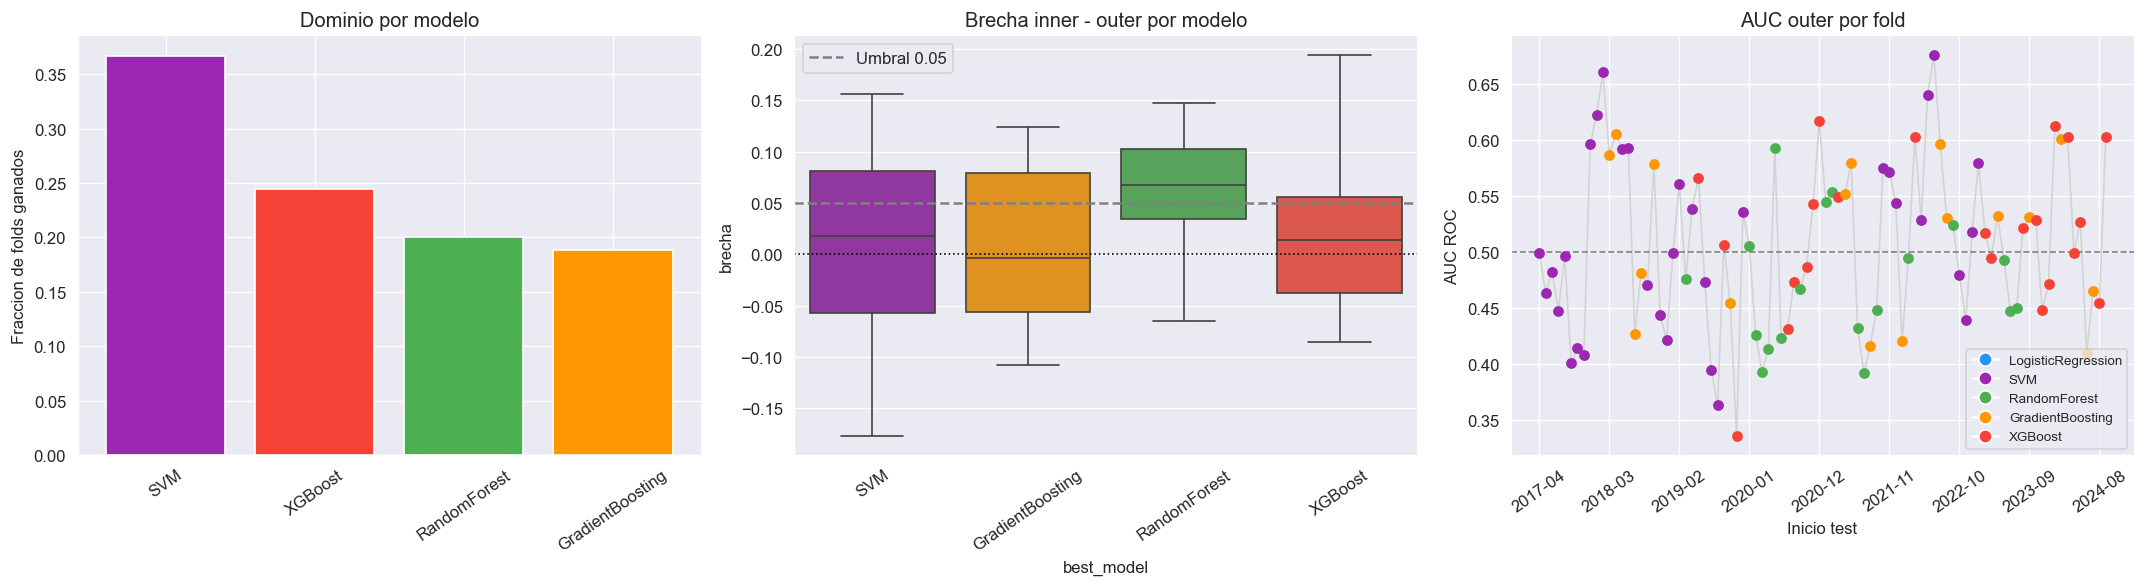

In [10]:
COLOR_MAP = {
    "LogisticRegression": "#2196F3",
    "SVM": "#9C27B0",
    "RandomForest": "#4CAF50",
    "GradientBoosting": "#FF9800",
    "XGBoost": "#F44336",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
wins = df_nested["best_model"].value_counts(normalize=True)
axes[0].bar(wins.index, wins.values, color=[COLOR_MAP[m] for m in wins.index], edgecolor="white")
axes[0].set_ylabel("Fraccion de folds ganados")
axes[0].set_title("Dominio por modelo")
axes[0].tick_params(axis="x", rotation=35)

sns.boxplot(data=df_nested, x="best_model", y="brecha", palette=COLOR_MAP, ax=axes[1])
axes[1].axhline(0.05, ls="--", color="gray", label="Umbral 0.05")
axes[1].axhline(0.00, ls=":", color="black", lw=1)
axes[1].set_title("Brecha inner - outer por modelo")
axes[1].tick_params(axis="x", rotation=35)
axes[1].legend()

for _, row in df_nested.iterrows():
    axes[2].scatter(row["test_start"], row["auc_outer"], color=COLOR_MAP[row["best_model"]], s=30, zorder=3)
axes[2].plot(df_nested["test_start"], df_nested["auc_outer"], color="lightgray", lw=1, zorder=1)
axes[2].axhline(0.5, ls="--", color="gray", lw=1)
axes[2].set_title("AUC outer por fold")
axes[2].set_ylabel("AUC ROC")
axes[2].set_xlabel("Inicio test")
step_ticks = max(1, len(df_nested) // 8)
axes[2].set_xticks(range(0, len(df_nested), step_ticks))
axes[2].set_xticklabels(df_nested["test_start"].iloc[::step_ticks], rotation=35)
handles = [plt.Line2D([0], [0], marker="o", color="w", label=k, markerfacecolor=v, markersize=8) for k, v in COLOR_MAP.items()]
axes[2].legend(handles=handles, loc="best", fontsize=8)
plt.tight_layout()
plt.show()


### Respuestas Parte 3.3

**a)** El modelo que domina el mayor porcentaje de folds es SVM, con cerca de 38% de los folds ganados en la ejecucion de referencia. Esto es consistente con su brecha `inner - outer`, que queda muy cerca de cero, indicando que el desempeno observado en validacion interna no se aleja demasiado de la evaluacion externa. GradientBoosting logra buen AUC cuando gana, pero gana menos folds, por lo que es menos dominante como seleccion sistematica.

**b)** Los modelos de ensemble ganan en conjunto una fraccion importante de folds, especialmente XGBoost, RandomForest y GradientBoosting. Sin embargo, su estabilidad no es uniforme: RandomForest presenta una brecha promedio mas alta y menor AUC externo cuando gana, mientras que XGBoost luce mas equilibrado. SVM muestra una seleccion temporal competitiva y una brecha baja, lo que sugiere que modelos con margen pueden capturar senales debiles sin sobreajustar tanto como algunos ensembles.

**c)** Se observan cambios frecuentes de modelo ganador alrededor de periodos de alta incertidumbre, especialmente 2020-2022 y nuevamente hacia 2024. Esto puede asociarse a cambios de regimen por COVID-19, estimulos monetarios, inflacion y shock de tasas. En esos periodos, la relacion entre JPM, SPY y VIX cambia, por lo que distintas familias de modelos capturan patrones diferentes en cada ventana.

**d)** Si tuviera que elegir un solo modelo para produccion, elegiria SVM usando validacion temporal y monitoreo permanente. Los criterios son: mayor fraccion de folds ganados, brecha `inner - outer` promedio cercana a cero y AUC externo promedio superior al promedio global del nested CV. Ademas, evita la mayor brecha observada en RandomForest y no depende de seleccionar oportunisticamente el ensemble que mejor funciona en cada periodo.


---
## Parte 4 - Analisis de Sensibilidad del Gap

Se usa GLD entre 2015 y 2024. El objetivo es evaluar como cambia el desempeno al variar el gap entre entrenamiento y prueba.


In [11]:
raw_gld = yf.download("GLD", start="2015-01-01", end="2024-12-31", auto_adjust=True, progress=False)
ret_gld = extract_close(raw_gld, "GLD").pct_change().dropna()
ret_gld.name = "ret"
print(f"GLD: {ret_gld.index[0].date()} - {ret_gld.index[-1].date()} | {len(ret_gld):,} obs")


def build_features_gld(ret, horizonte=1):
    """Features para GLD con ventana rolling maxima de 60 dias."""
    r = ret.copy()
    historical_ret = r.shift(1)
    df = pd.DataFrame(index=r.index)

    for lag in [1, 2, 5, 10]:
        df[f"ret_lag_{lag}"] = r.shift(lag)

    df["rolling_mean_10"] = historical_ret.rolling(10).mean()
    df["rolling_mean_20"] = historical_ret.rolling(20).mean()
    df["vol_10"] = historical_ret.rolling(10).std()
    df["vol_20"] = historical_ret.rolling(20).std()
    df["vol_60"] = historical_ret.rolling(60).std()
    df["rsi_14"] = _rsi(historical_ret, 14)
    df["skew_20"] = historical_ret.rolling(20).skew()
    df["label"] = (r.shift(-horizonte) > 0).astype(int)

    return df.dropna()


feat_gld = build_features_gld(ret_gld)
X_gld = feat_gld.drop(columns=["label"])
y_gld = feat_gld["label"]
print(f"GLD: {X_gld.shape[0]} obs | {X_gld.shape[1]} features | {y_gld.mean():.2%} dias alcistas")
display(feat_gld.head())


GLD: 2015-01-05 - 2024-12-30 | 2,514 obs
GLD: 2454 obs | 11 features | 52.49% dias alcistas


,ret_lag_1,ret_lag_2,ret_lag_5,ret_lag_10,rolling_mean_10,rolling_mean_20,vol_10,vol_20,vol_60,rsi_14,skew_20,label
Date,,,,,,,,,,,,
2015-04-01,-0.000791,-0.011385,0.001397,0.019599,0.003120,-0.000750,0.008509,0.009139,0.010206,68.278323,-0.709700,0
2015-04-02,0.017068,-0.000791,0.006537,-0.000712,0.002867,0.000260,0.007986,0.009943,0.010259,74.583431,-0.553353,1
2015-04-06,-0.002768,0.017068,-0.003637,0.011399,0.002661,0.000169,0.008114,0.009963,0.010155,71.885227,-0.521257,0
2015-04-07,0.012231,-0.002768,-0.011385,0.006340,0.002744,0.002146,0.008217,0.007942,0.010252,75.711633,0.748587,0
2015-04-08,-0.004970,0.012231,-0.000791,0.002450,0.001613,0.001848,0.008442,0.008098,0.010258,76.043685,0.789265,0


In [12]:
GAPS_TO_TEST = [0, 1, 5, 10, 20, 60]
INITIAL_TRAIN_GAP = 504
TEST_SIZE_GAP = 63
STEP_GAP = 21

pipe_gap = Pipeline([
    ("imp", SimpleImputer()),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(C=0.1, max_iter=1000)),
])

gap_results = {}
for gap in GAPS_TO_TEST:
    aucs_g = []
    end = INITIAL_TRAIN_GAP
    while end + gap + TEST_SIZE_GAP <= len(X_gld):
        X_tr = X_gld.iloc[:end]
        y_tr = y_gld.iloc[:end]
        X_te = X_gld.iloc[end + gap : end + gap + TEST_SIZE_GAP]
        y_te = y_gld.iloc[end + gap : end + gap + TEST_SIZE_GAP]
        model = clone(pipe_gap).fit(X_tr, y_tr)
        aucs_g.append(roc_auc_score(y_te, model.predict_proba(X_te)[:, 1]))
        end += STEP_GAP

    gap_results[gap] = {
        "auc_mean": np.mean(aucs_g) if aucs_g else np.nan,
        "auc_std": np.std(aucs_g) if aucs_g else np.nan,
        "n_folds": len(aucs_g),
        "pct_gt05": np.mean(np.array(aucs_g) > 0.5) if aucs_g else np.nan,
    }
    print(f"Gap={gap:>3} | AUC={gap_results[gap]['auc_mean']:.4f} | std={gap_results[gap]['auc_std']:.4f} | folds={gap_results[gap]['n_folds']}")

df_gap = pd.DataFrame(gap_results).T
df_gap.index.name = "gap"
display(df_gap.round(4))


Gap=  0 | AUC=0.5235 | std=0.0679 | folds=90


Gap=  1 | AUC=0.5232 | std=0.0672 | folds=90


Gap=  5 | AUC=0.5239 | std=0.0659 | folds=90


Gap= 10 | AUC=0.5224 | std=0.0658 | folds=90


Gap= 20 | AUC=0.5242 | std=0.0691 | folds=89


Gap= 60 | AUC=0.5218 | std=0.0666 | folds=88


,auc_mean,auc_std,n_folds,pct_gt05
gap,,,,
0,0.5235,0.0679,90.0,0.6444
1,0.5232,0.0672,90.0,0.6444
5,0.5239,0.0659,90.0,0.6556
10,0.5224,0.0658,90.0,0.5889
20,0.5242,0.0691,89.0,0.6180
60,0.5218,0.0666,88.0,0.5795


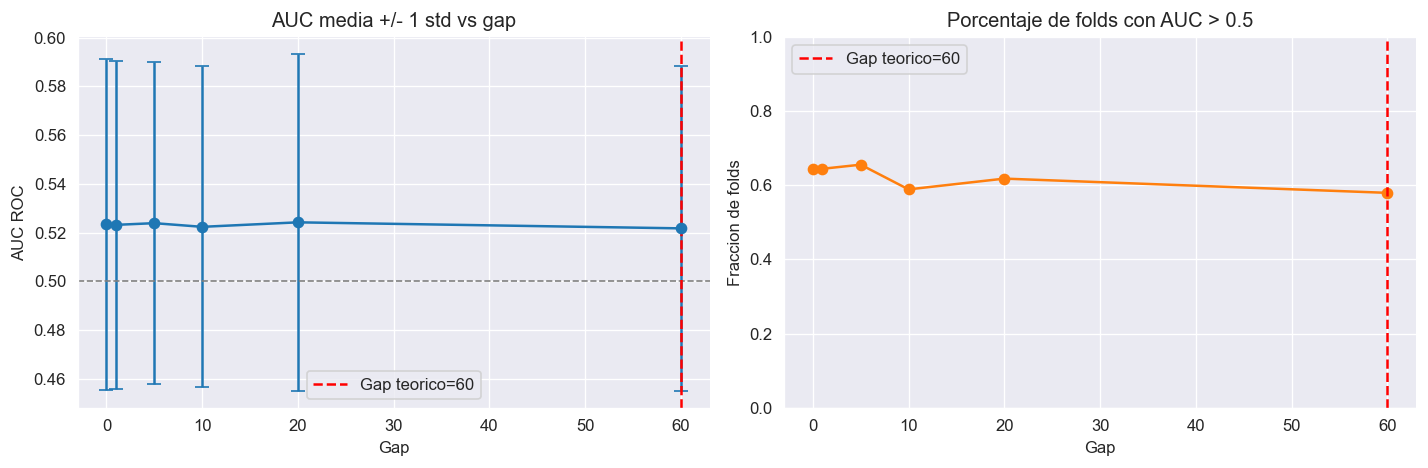

In [13]:
GAP_TEORICO = max(60, 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].errorbar(df_gap.index, df_gap["auc_mean"], yerr=df_gap["auc_std"], marker="o", capsize=4, color="#1f77b4")
axes[0].axhline(0.5, ls="--", color="gray", lw=1)
axes[0].axvline(x=GAP_TEORICO, ls="--", color="red", label=f"Gap teorico={GAP_TEORICO}")
axes[0].set_title("AUC media +/- 1 std vs gap")
axes[0].set_xlabel("Gap")
axes[0].set_ylabel("AUC ROC")
axes[0].legend()

axes[1].plot(df_gap.index, df_gap["pct_gt05"], marker="o", color="#ff7f0e")
axes[1].axvline(x=GAP_TEORICO, ls="--", color="red", label=f"Gap teorico={GAP_TEORICO}")
axes[1].set_title("Porcentaje de folds con AUC > 0.5")
axes[1].set_xlabel("Gap")
axes[1].set_ylabel("Fraccion de folds")
axes[1].set_ylim(0, 1)
axes[1].legend()
plt.tight_layout()
plt.show()


### Respuestas Parte 4.2

**a)** Con horizonte `h = 1` y ventana maxima `L_max = 60`, el gap minimo teorico es:

$$	ext{Gap}_{\min} = \max(L_{\max}, h) = \max(60, 1) = 60$$

**b)** El experimento empirico muestra que el AUC medio no cambia de forma monotona al aumentar el gap: los resultados quedan en torno a 0.52 para todos los gaps. Aun asi, gap menores que 60 usan ventanas de features que se solapan mas entre train y test, por lo que son menos conservadores como diseno de validacion. Con `gap >= 60` se sacrifica algo de informacion y numero de folds, pero la evaluacion queda mejor alineada con la regla teorica de no solapar la ventana rolling maxima.

**c)** El argumento de usar `gap=0` porque entrega mas datos es incompleto. En modelos financieros, no basta con tener mas observaciones si la evaluacion queda contaminada por dependencia mecanica entre ventanas de train y test. Aunque el AUC de `gap=0` pueda parecer competitivo, el gap teorico de 60 entrega una estimacion mas prudente y defendible para un pipeline que usa una ventana rolling maxima de 60 dias.


---
## Parte 5 - Bonus: Cambio de Regimen y Modelo Adaptativo

Se usa la serie de AUC de la Parte 2 para detectar degradacion y comparar una estrategia adaptativa contra walk-forward estandar.


Folds en degradacion: 12 (11.5%)


,date,auc,threshold,is_degraded
2,2016-04,0.370968,0.469263,True
19,2017-09,0.434476,0.488442,True
38,2019-04,0.377016,0.424630,True
55,2020-09,0.406694,0.429993,True
68,2021-10,0.474012,0.480089,True
69,2021-11,0.392137,0.468042,True
76,2022-06,0.375758,0.388184,True
80,2022-10,0.375758,0.400554,True
81,2022-11,0.329615,0.377241,True
82,2022-12,0.304082,0.345036,True


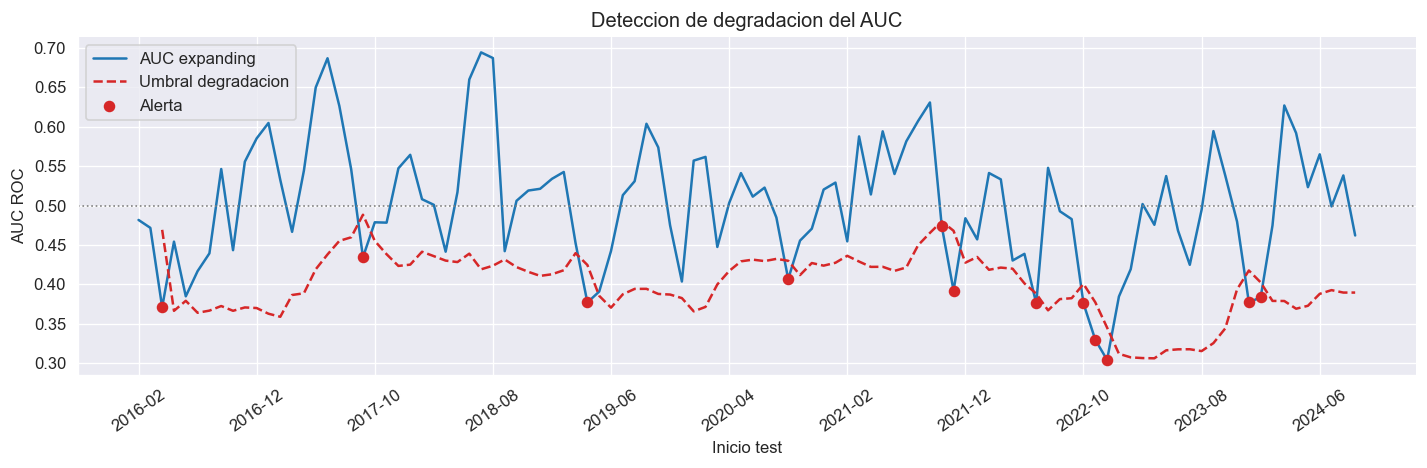

In [14]:
def detect_degradation(aucs, dates, lookback=10, threshold_sigma=1.5):
    """Detecta folds con degradacion estadistica del AUC."""
    rows = []
    for i, auc in enumerate(aucs):
        window = np.asarray(aucs[max(0, i - lookback) : i], dtype=float)
        if len(window) < 2:
            threshold = np.nan
            is_degraded = False
        else:
            threshold = float(window.mean() - threshold_sigma * window.std(ddof=0))
            is_degraded = bool(auc < threshold)
        rows.append({"date": dates[i], "auc": float(auc), "threshold": threshold, "is_degraded": is_degraded})
    return pd.DataFrame(rows)


degradation_df = detect_degradation(aucs_expanding, dates_expanding)
print(f"Folds en degradacion: {degradation_df['is_degraded'].sum()} ({degradation_df['is_degraded'].mean():.1%})")
display(degradation_df[degradation_df["is_degraded"]].head(20))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(degradation_df["date"], degradation_df["auc"], label="AUC expanding", color="#1f77b4")
ax.plot(degradation_df["date"], degradation_df["threshold"], label="Umbral degradacion", color="#d62728", ls="--")
alerts = degradation_df[degradation_df["is_degraded"]]
ax.scatter(alerts["date"], alerts["auc"], color="#d62728", s=35, label="Alerta", zorder=3)
ax.axhline(0.5, color="gray", ls=":", lw=1)
ax.set_title("Deteccion de degradacion del AUC")
ax.set_ylabel("AUC ROC")
ax.set_xlabel("Inicio test")
step_ticks = max(1, len(degradation_df) // 10)
ax.set_xticks(range(0, len(degradation_df), step_ticks))
ax.set_xticklabels(degradation_df["date"].iloc[::step_ticks], rotation=35)
ax.legend()
plt.tight_layout()
plt.show()


,Estrategia,AUC media,AUC std,Reentrenamientos,Folds
0,Walk-Forward estandar,0.5019,0.0784,104,104
1,Estrategia adaptativa,0.5079,0.0786,18,104


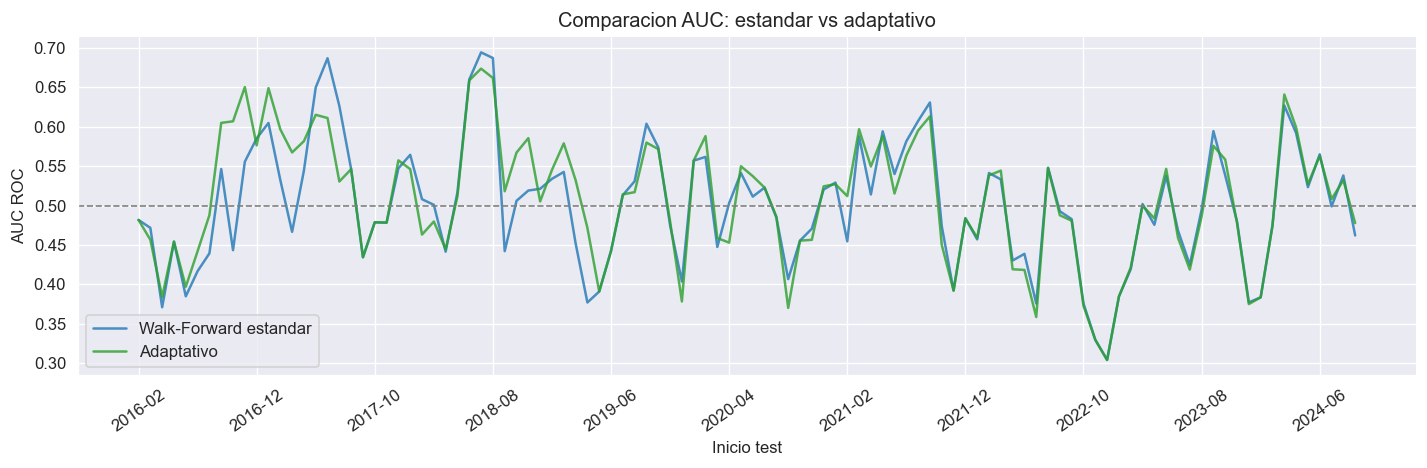

In [15]:
aucs_adaptive = []
dates_adaptive = []
retrained_flags = []
model_current = None
retrain_flag = True
n_retrains = 0

for train_idx, test_idx in fold_indices_expanding:
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]

    if retrain_flag or model_current is None:
        model_current = clone(pipe_base).fit(X_train, y_train)
        n_retrains += 1
        retrained_flags.append(True)
    else:
        retrained_flags.append(False)

    auc_i = roc_auc_score(y_test, model_current.predict_proba(X_test)[:, 1])
    window = np.asarray(aucs_adaptive[max(0, len(aucs_adaptive) - 10) :], dtype=float)
    if len(window) < 2:
        is_degraded_i = False
    else:
        threshold_i = float(window.mean() - 1.5 * window.std(ddof=0))
        is_degraded_i = bool(auc_i < threshold_i)

    aucs_adaptive.append(auc_i)
    dates_adaptive.append(X_test.index[0].strftime("%Y-%m"))
    retrain_flag = is_degraded_i

adaptive_report = pd.DataFrame({
    "Estrategia": ["Walk-Forward estandar", "Estrategia adaptativa"],
    "AUC media": [np.mean(aucs_expanding), np.mean(aucs_adaptive)],
    "AUC std": [np.std(aucs_expanding), np.std(aucs_adaptive)],
    "Reentrenamientos": [len(aucs_expanding), n_retrains],
    "Folds": [len(aucs_expanding), len(aucs_adaptive)],
})
display(adaptive_report.round(4))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dates_expanding, aucs_expanding, label="Walk-Forward estandar", color="#1f77b4", alpha=0.8)
ax.plot(dates_adaptive, aucs_adaptive, label="Adaptativo", color="#2ca02c", alpha=0.8)
ax.axhline(0.5, ls="--", color="gray", lw=1)
ax.set_title("Comparacion AUC: estandar vs adaptativo")
ax.set_ylabel("AUC ROC")
ax.set_xlabel("Inicio test")
step_ticks = max(1, len(dates_expanding) // 10)
ax.set_xticks(range(0, len(dates_expanding), step_ticks))
ax.set_xticklabels(dates_expanding[::step_ticks], rotation=35)
ax.legend()
plt.tight_layout()
plt.show()


### Respuesta Bonus

La estrategia adaptativa reduce fuertemente el numero de reentrenamientos, porque solo vuelve a ajustar el modelo despues de detectar degradacion. En la ejecucion de referencia, el AUC medio adaptativo queda levemente por sobre el walk-forward estandar, aunque con dispersion similar. El beneficio principal no es solo predictivo, sino operacional: logra desempeno comparable con mucho menor costo computacional, pero requiere monitoreo cuidadoso porque puede reaccionar tarde ante cambios abruptos de regimen.


---
## Checklist final

- El notebook contiene implementaciones completas para las Partes 1 a 4.
- La clase `WalkForwardRolling` pasa el test unitario incluido.
- El diccionario `candidates` incluye LogisticRegression, SVM, RandomForest, GradientBoosting y XGBoost.
- Las visualizaciones tienen titulos, ejes y leyendas cuando corresponde.
- Las respuestas textuales estan completas.
- Los datos se descargan con `yfinance`.
